# Question 1

In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
img = cv2.imread("/content/sample_data/emma.jpg")
outdir = "q1_outputs"; os.makedirs(outdir, exist_ok=True)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

lut = np.zeros(256, np.uint8)

for r in range(0, 50):
    lut[r] = r

m1 = (255-100)/(150-50)
for r in range(50, 150):
    lut[r] = np.clip(int(round(100 + m1*(r-50))), 0, 255)

m2 = (255-160)/(255-150)
for r in range(150, 256):
    lut[r] = np.clip(int(round(160 + m2*(r-150))), 0, 255)

lut[50]  = 100
lut[150] = 160

out = cv2.LUT(gray, lut)

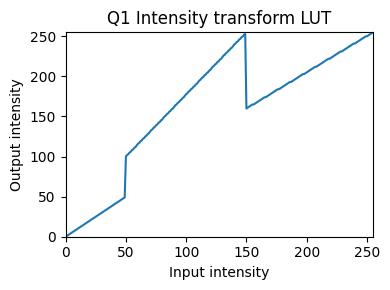

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(np.arange(256), lut)
plt.title("Q1 Intensity transform LUT")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.xlim(0,255); plt.ylim(0,255)
plt.tight_layout()
plt.savefig("q1_emma_curve.png", dpi=150)
plt.show()

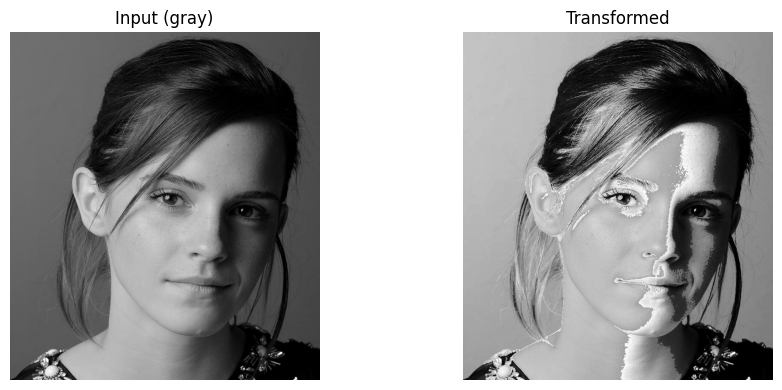

In [ ]:
cv2.imwrite(os.path.join(outdir, "q1_emma_input.png"), gray)
cv2.imwrite(os.path.join(outdir, "q1_emma_output.png"), out)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gray, cmap="gray"); plt.title("Input (gray)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(out, cmap="gray"); plt.title("Transformed"); plt.axis("off")
plt.tight_layout(); plt.show()